In [2]:
import numpy as np
import matplotlib as mpl
import glob
import os
import matplotlib.pyplot as plt
import numpy.ma as ma
import matplotlib.gridspec as gridspec
from scipy import stats
import xarray as xr
import commondefs as myF
plt.rcParams.update({'font.size': 12})

In [3]:
mydir = '../processed_netcdf/'
nm = 12
gencolours = ['blue','red','green','black']

In [4]:
# trends from piControl
piCtrend_dict = {} 
model_name = xr.open_dataset(mydir+'processed_CMIP6_sia_ssp245_r1_updated.nc').name        
myfiles = [mydir+'/piControl/CMIP6_sia_sh/'+f for f in os.listdir(mydir+'/piControl/CMIP6_sia_sh/')]
for n,file in enumerate(myfiles):
    ds = xr.open_dataset(file,decode_times=False)
    if len(ds.sia.shape) ==3:
        sia = ds.sia[:,0,0].values
    else:
        sia = ds.sia.values

    if file.split('_')[5] in [f.strip().split('_')[0] for f in model_name.values]:
        if len(sia)>nm*40:
            ny = int(len(sia)/nm)
            sia_ym = np.reshape(sia[:ny*nm],(ny,nm))
    
            sep_slopes = []
            feb_slopes = []
            for y in range(ny-39):
                feb_slope, intercept, r_value, p_value, std_err = stats.linregress(np.arange(40),sia_ym[y:40+y,1])
                sep_slope, intercept, r_value, p_value, std_err = stats.linregress(np.arange(40),sia_ym[y:40+y,8])

                sep_slopes.append(10.*sep_slope)
                feb_slopes.append(10.*feb_slope)
                
            piCtrend_dict[file.split('_')[5]] = [feb_slopes,sep_slopes]

In [5]:
ensemble_ds = xr.open_dataset('../processed_netcdf/processed_CMIP6_sia_ssp245_allr_updated.nc').sel(year=slice('1979','2018'))

ensemble_ds = myF.add_trend_stats_to_ds (ensemble_ds, ensemble_ds.sia_sh, 'sia_sh')
ensemble_ds = myF.add_trend_stats_to_ds (ensemble_ds, ensemble_ds.gmst, 'gmst')
ensemble_ds = myF.add_trend_stats_to_ds (ensemble_ds, ensemble_ds.sia_nh.mean(dim='month'), 'sia_nh_annmean')
ensemble_ds = myF.add_trend_stats_to_ds (ensemble_ds, ensemble_ds.sia_sh.mean(dim='month'), 'sia_sh_annmean')
print(ensemble_ds.name.values)

['ACCESS-CM2_r1i1p1f1' 'ACCESS-ESM1-5_r1i1p1f1' 'ACCESS-ESM1-5_r2i1p1f1'
 'ACCESS-ESM1-5_r3i1p1f1' 'AWI-CM-1-1-MR_r1i1p1f1' 'BCC-CSM2-MR_r1i1p1f1'
 'CAMS-CSM1-0_r1i1p1f1' 'CAMS-CSM1-0_r2i1p1f1' 'CESM2_r1i1p1f1'
 'CESM2-WACCM_r1i1p1f1' 'CNRM-CM6-1_r1i1p1f2' 'CNRM-CM6-1-HR_r1i1p1f2'
 'CNRM-ESM2-1_r1i1p1f2' 'CanESM5_r1i1p1f1' 'CanESM5_r2i1p1f1'
 'CanESM5_r3i1p1f1' 'CanESM5_r4i1p1f1' 'CanESM5_r5i1p1f1'
 'CanESM5_r6i1p1f1' 'CanESM5_r7i1p1f1' 'CanESM5_r8i1p1f1'
 'CanESM5_r9i1p1f1' 'CanESM5_r10i1p1f1' 'EC-Earth3_r1i1p1f1'
 'EC-Earth3_r2i1p1f1' 'EC-Earth3_r4i1p1f1' 'EC-Earth3_r12i1p1f1'
 'EC-Earth3_r14i1p1f1' 'EC-Earth3_r16i1p1f1' 'EC-Earth3_r17i1p1f1'
 'EC-Earth3_r18i1p1f1' 'EC-Earth3_r19i1p1f1' 'EC-Earth3_r20i1p1f1'
 'EC-Earth3_r21i1p1f1' 'EC-Earth3_r22i1p1f1' 'EC-Earth3_r24i1p1f1'
 'EC-Earth3-Veg_r1i1p1f1' 'EC-Earth3-Veg_r2i1p1f1'
 'EC-Earth3-Veg_r4i1p1f1' 'FGOALS-f3-L_r1i1p1f1' 'FIO-ESM-2-0_r1i1p1f1'
 'FIO-ESM-2-0_r2i1p1f1' 'FIO-ESM-2-0_r3i1p1f1' 'GFDL-CM4_r1i1p1f1'
 'GFDL-ESM4_r1i1p1f1' '

/Users/lettieroach/anaconda3/lib/python3.7/site-packages/xarray/core/nanops.py:140: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis=axis, dtype=dtype)


In [6]:
obs_ds =  xr.open_dataset(mydir+'processed_OBS_sia_1979-2018.nc').sel(year=slice('1979','2018'))
obs_ds = myF.add_trend_stats_to_ds (obs_ds, obs_ds.sia_nh, 'sia_nh')
obs_ds = myF.add_trend_stats_to_ds (obs_ds, obs_ds.sia_sh, 'sia_sh')
obs_ds = myF.add_trend_stats_to_ds (obs_ds, obs_ds.sia_nh.mean(dim='month'), 'sia_nh_annmean')
obs_ds = myF.add_trend_stats_to_ds (obs_ds, obs_ds.sia_sh.mean(dim='month'), 'sia_sh_annmean')
obs_ds = myF.add_trend_stats_to_ds (obs_ds, obs_ds.sia_sh.sel(year=slice('1979','2014')), 'sia_sh_1979to2014')   

In [7]:
#NOAA - 1971-2000 climatology
#Berkeley - 1951-1980 climatology
#HadCRUT - 1961 - 1990 climatology
#GISTEMP - 1951 - 1980 climatology
array_names = ['slope', 'intercept', 'r_value', 'p_value', 'std_err']
array_names = ['gmst_'+f for f in array_names]
onames = ['noaa','gistemp','berkeley','HadCRUT']
anomperiodst = ['1880','1850','1850','1850'] 
gmst_stats = np.zeros([4,5])
for o,oname in enumerate(onames):
    ds = xr.open_dataset('../processed_netcdf/GMST_'+oname+'_yearly.nc').sel(time=slice('1979','2018'))
    anompds = xr.open_dataset('../processed_netcdf/GMST_'+oname+'_yearly.nc').sel(time=slice(anomperiodst[o],'1900')).tas_ano[:,0,0]
    
    da = ds.tas_ano[:,0,0]
    if len(da.shape) > 1:
        da = da[:,0]
        anompds = anompds[:,0]
    
    da.values = da.values - anompds.mean(dim='time').values
    #print(anompds)
    
    gmst_stats[o,:] = stats.linregress(np.arange(len(ds.time)),da)

for a, arr_name in enumerate(array_names):
    if a ==0:
        var1 = xr.DataArray(gmst_stats[:,a],dims=['name'])
        gmst_ds = var1.to_dataset(name = arr_name)
    else:
        gmst_ds[arr_name] = xr.DataArray(gmst_stats[:,a],dims=['name'])
gmst_ds['name'] = onames
print(gmst_ds)

<xarray.Dataset>
Dimensions:         (name: 4)
Coordinates:
  * name            (name) <U8 'noaa' 'gistemp' 'berkeley' 'HadCRUT'
Data variables:
    gmst_slope      (name) float64 0.01692 0.01748 0.01875 0.01759
    gmst_intercept  (name) float64 0.3798 0.3732 0.4071 0.3223
    gmst_r_value    (name) float64 0.9084 0.9072 0.921 0.9121
    gmst_p_value    (name) float64 5.743e-16 7.208e-16 3.809e-17 2.689e-16
    gmst_std_err    (name) float64 0.001263 0.001314 0.001286 0.001282


In [8]:
corr_nh = []
corr_sh = []

for o,oname in enumerate(onames):
    ds = xr.open_dataset('../processed_netcdf/GMST_'+oname+'_yearly.nc').sel(time=slice('1979','2018'))
    anompds = xr.open_dataset('../processed_netcdf/GMST_'+oname+'_yearly.nc').sel(time=slice(anomperiodst[o],'1900')).tas_ano[:,0,0]
    
    da = ds.tas_ano[:,0,0]
    if len(da.shape) > 1:
        da = da[:,0]
        anompds = anompds[:,0]
    
    da.values = da.values - anompds.mean(dim='time').values
    
    
    for sio in np.arange(3):
        xdata = da.values#-np.arange(40)*gmst_ds.gmst_slope.isel(name=0).values + gmst_ds.gmst_intercept.isel(name=0).values
        bestfity = obs_ds.isel(name=sio).sia_nh_annmean_slope.values*np.arange(40) + obs_ds.isel(name=sio).sia_nh_annmean_intercept.values
        corr, p = stats.pearsonr(xdata,obs_ds.sia_nh.mean(dim='month').isel(name=sio))#-bestfity)
        corr_nh.append(corr)
        bestfity = obs_ds.isel(name=sio).sia_sh_annmean_slope.values*np.arange(40) + obs_ds.isel(name=sio).sia_sh_annmean_intercept.values
        
        corr, p = stats.pearsonr(xdata,obs_ds.sia_sh.mean(dim='month').isel(name=sio))#-bestfity)
        corr_sh.append(corr)

corr_nh = np.mean(np.asarray(corr_nh).reshape([4,3]),axis=0)
corr_sh = np.mean(np.asarray(corr_sh).reshape([4,3]),axis=0)
obs_corr = [corr_sh,corr_nh]

Sep  Trend in observations  0.11719025591897395 0.2658534966636145
Sep  Trend in observations  0.06750245736941009 0.19422537794649117
Sep  Trend in observations  0.1686565672285415 0.3461787409789253
Feb  Trend in observations  0.034967634848004164 0.09041938077578089
Feb  Trend in observations  0.06712417761622132 0.1161589300648499
Feb  Trend in observations  0.05644932176963136 0.1112877027152339
74


/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


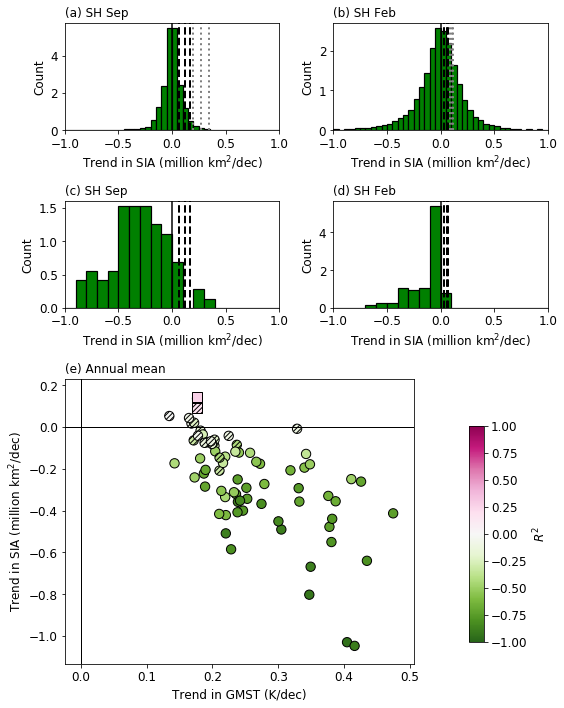

In [15]:
h=0
plt.rcParams.update({'font.size': 12})
colours = plt.cm.PiYG_r(np.linspace(0,1,200))
fig = plt.figure(figsize=(8,10))

gs = gridspec.GridSpec(4, 4)

for m, month in enumerate([9,2]):
    ax1 = plt.subplot(gs[0, 2*m:(2*m+2)])
    
    mydata = [piCtrend_dict[f][m] for f in piCtrend_dict] #list of lists
    flatdata = [item for sublist in mydata for item in sublist]
    
    ax1.hist(flatdata, bins=np.linspace(-1,1,41),density=True,
             edgecolor='black',facecolor='green', linewidth=1.2)
    
    ax1.set_title(myF.alphabet[m]+' SH '+myF.months[month-1],loc='left',fontsize=12)
    ax1.axvline(x=0,c='black',linestyle='-')
    
    for o in range(3):
        ax1.axvline(x=10.*obs_ds.isel(name=o).sel(month=month).sia_sh_slope,c='black',linestyle='--',linewidth=2)
        print(myF.months[month-1],' Trend in observations ',10.*obs_ds.isel(name=o).sel(month=month).sia_sh_slope.values,
             10.*obs_ds.isel(name=o).sel(month=month).sia_sh_1979to2014_slope.values)
        ax1.axvline(x=10.*obs_ds.isel(name=o).sel(month=month).sia_sh_1979to2014_slope,c='grey',linestyle=':',linewidth=2)
           
    ax1.set_xlim([-1,1])
    ax1.set_ylabel('Count')
    ax1.set_xlabel(r'Trend in SIA (million km$^2$/dec)')

    
for m, month in enumerate([9,2]):
    ax1 = plt.subplot(gs[1, 2*m:(2*m+2)])
   
    ax1.hist(10.*ensemble_ds.sia_sh_slope.sel(month=month), bins=np.linspace(-1,1,21),density=True,
             edgecolor='black',facecolor='green', linewidth=1.2)
    
    ax1.set_title(myF.alphabet[m+2]+' SH '+myF.months[month-1],loc='left',fontsize=12)
    ax1.axvline(x=0,c='black',linestyle='-')
    
    for o in range(3):
        ax1.axvline(x=10.*obs_ds.isel(name=o).sel(month=month).sia_sh_slope,c='black',linestyle='--',linewidth=2)
  
    ax1.set_xlim([-1,1])
    ax1.set_ylabel('Count')
    ax1.set_xlabel(r'Trend in SIA (million km$^2$/dec)')

    
ax = plt.subplot(gs[2:,:3])
ax.axhline(y=0,c='k',linewidth=1)
ax.axvline(x=0,c='k',linewidth=1)
correlation = []

print(len(ensemble_ds.name.values))

for m in range(len(ensemble_ds.name.values)):

    bestfitx = np.arange(40)*ensemble_ds.gmst_slope.values[m]+ensemble_ds.gmst_intercept.values[m]
    xdata = ensemble_ds['gmst'].values[m,:]
    bestfity = np.arange(40)*ensemble_ds['sia_sh_annmean_slope'].values[m] + ensemble_ds['sia_sh_annmean_intercept'].values[m]
    ydata = ensemble_ds['sia_sh'].mean(dim='month').values[m,:]#-bestfity


    if len(xdata[~np.isnan(xdata)])>2:
        corr, p = stats.pearsonr(xdata[~np.isnan(xdata)],
                                 ydata[~np.isnan(xdata)])

        fcolour = colours[int(100*corr+100)] 
        
     
    if ensemble_ds['sia_sh_annmean_p_value'][m].values<0.05:
        mk =''
    else:
        mk = '/////'
   
    ax.scatter(10.*ensemble_ds['gmst_slope'][m],10.*ensemble_ds['sia_sh_annmean_slope'][m],
             s=87,edgecolors='black',facecolor=fcolour, linewidth=1,marker ='o',hatch=mk)
    
    
for o in range(3):
    fcolour = colours[int(100*obs_corr[h][o]+100)] 
   
    if obs_ds['sia_sh_annmean_p_value'].isel(name=o).values<0.05:      
        mk = ''
    else:
        mk= '/////'
   
    ax.scatter(10.*gmst_ds.gmst_slope.mean(), 10.*obs_ds['sia_sh_annmean_slope'].isel(name=o),
                 s=110,marker='s',hatch=mk,edgecolors='black',facecolor=fcolour,linewidth=1)


ax.set_xlabel('Trend in GMST (K/dec)',fontsize=12)
ax.set_ylabel('Trend in SIA (million km$^2$/dec)',fontsize=12)
ax.set_title('(e) Annual mean',loc='left',fontsize=12)


ax2  = fig.add_axes([0.825,0.1,0.025,0.3])
cmap = mpl.cm.PiYG_r
norm = mpl.colors.Normalize(vmin=-1, vmax=1)
cb1 = mpl.colorbar.ColorbarBase(ax2, cmap=cmap,norm=norm,orientation='vertical')
cb1.set_label('$R^2$')
    
plt.tight_layout()
fig.savefig('fig3.pdf',bbox_inches='tight',dpi=300)
plt.show()
plt.close()